In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, datasets
from tensorflow.keras.models import Sequential

2026-06-05 17:44:17.189367: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780681457.470353      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780681457.551135      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780681458.226740      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780681458.226799      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780681458.226803      16 computation_placer.cc:177] computation placer alr

In [2]:
(x_train,y_train),(x_test,y_test) = datasets.cifar10.load_data()
x_train.shape,y_test.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 154s 1us/step


((50000, 32, 32, 3), (10000, 1))

In [3]:
def plot_data(X,y,index):
  plt.imshow(X[index])
  plt.xlabel(y[index])
  plt.legend()

/tmp/ipykernel_16/3007419609.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


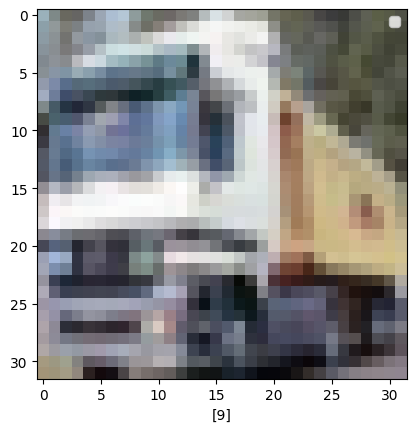

In [4]:
plot_data(x_train,y_train,1)


/tmp/ipykernel_16/3007419609.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


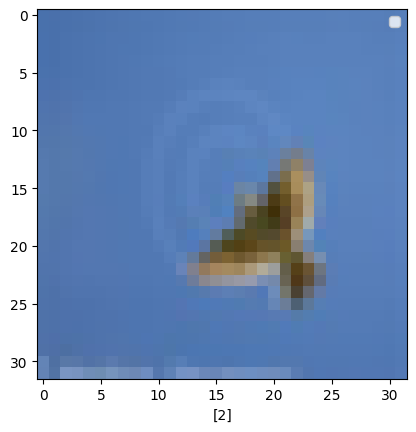

In [5]:
#plt.figure(figsize=(0.1,0.1))
plot_data(x_test,y_test,1587)


2026-06-05 17:47:17.462492: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


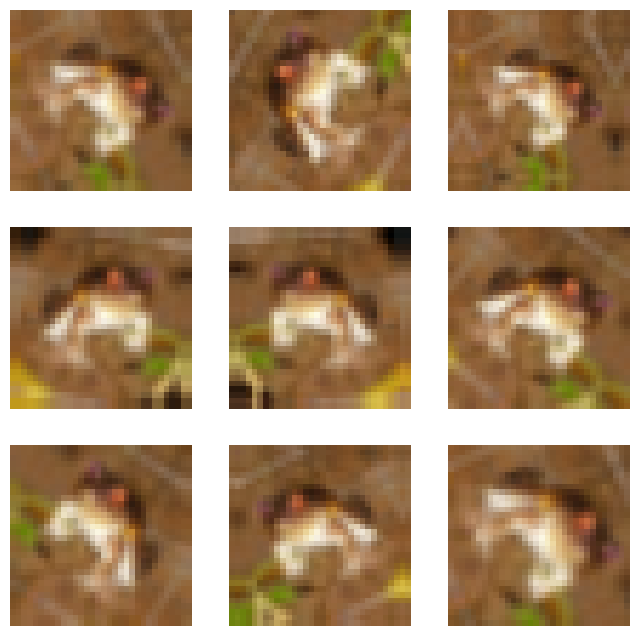

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

plt.figure(figsize=(8,8))

for i in range(9):
    augmented_image = data_augmentation(tf.expand_dims(x_train[0], 0))

    plt.subplot(3,3,i+1)
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.axis("off")

plt.show()

In [7]:
# without augmentation

cnn = Sequential([
    layers.Rescaling(1./255, input_shape=(32,32,3)),
    layers.Conv2D(filters=32, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=40, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((1,1)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.fit(x_train, y_train, epochs=10, batch_size=64)
cnn.evaluate(x_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.4468 - loss: 1.5261
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.5853 - loss: 1.1750
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.6413 - loss: 1.0176
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.6793 - loss: 0.9173
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.7040 - loss: 0.8413
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.7238 - loss: 0.7847
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.7446 - loss: 0.7295
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.7613 - loss: 0.6824
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.7771 - loss: 0.6316
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.7953 - loss: 0.5838
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6691 - loss: 1.0148


[1.014808177947998, 0.6690999865531921]

In [8]:
# with augmentation

cnn1 = Sequential([
    layers.Rescaling(1./255, input_shape=(32,32,3)),
    data_augmentation,
    layers.Conv2D(filters=32, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=40, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((1,1)),
    layers.Flatten(),
    layers.Dense(640, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

cnn1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn1.fit(x_train, y_train, epochs=10, batch_size=64)
cnn1.evaluate(x_test, y_test)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 74ms/step - accuracy: 0.3711 - loss: 1.7400
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.4692 - loss: 1.4853
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.5098 - loss: 1.3735
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.5378 - loss: 1.2976
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.5558 - loss: 1.2494
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.5723 - loss: 1.2037
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.5882 - loss: 1.1660
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.5973 - loss: 1.1349
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.6059 - loss: 1.1135
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 76ms/step - accuracy: 0.6158 - loss: 1.0943
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6146 - loss: 1.1271


[1.127131462097168, 0.6146000027656555]

In [9]:
cnn1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 40)     │        11,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 640)            │     4,327,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,143,512 (50.14 MB)

 Trainable params: 4,381,170 (16.71 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,762,342 (33.43 MB)

In [10]:
y_pred = cnn1.predict(x_test)
y_pred = np.array([np.argmax(i) for i in y_pred])
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


array([3, 8, 8, 0, 4])

              precision    recall  f1-score   support

           0       0.60      0.77      0.67      1000
           1       0.58      0.86      0.69      1000
           2       0.62      0.43      0.51      1000
           3       0.54      0.30      0.39      1000
           4       0.62      0.46      0.53      1000
           5       0.56      0.54      0.55      1000
           6       0.72      0.65      0.69      1000
           7       0.59      0.72      0.65      1000
           8       0.78      0.71      0.74      1000
           9       0.57      0.68      0.62      1000

    accuracy                           0.61     10000
   macro avg       0.62      0.61      0.60     10000
weighted avg       0.62      0.61      0.60     10000



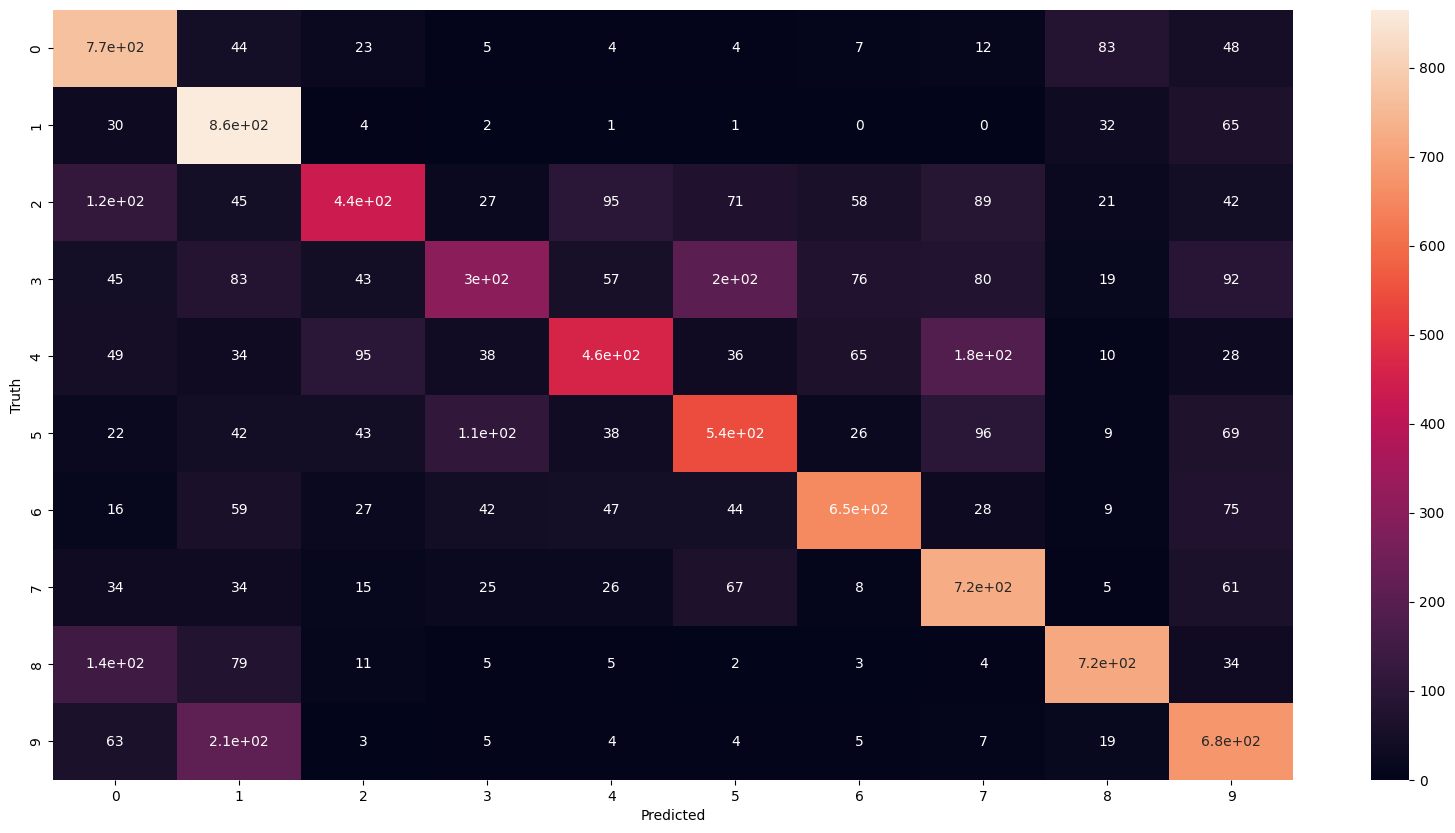

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(20,10))
sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()
